# Preprocessing Northern Hemisphere Radio Maps (Coarse Resolution)

## Overview

This notebook preprocesses radio continuum maps for synchrotron curvature analysis in the **Northern Hemisphere** at **coarse angular resolution** (~5 degree FWHM).

### Input Data Sources

| Frequency Range (MHz) | Survey | Resolution | Reference |
|----------------------|--------|------------|-----------|
| 22 | WMAP K-band | 53 arcmin | [WMAP DR5](https://lambda.gsfc.nasa.gov/product/wmap/dr5/) |
| 41.8-73.2 | OVRO-LWA | ~15-18 arcmin | [Eastwood et al. 2018](https://arxiv.org/abs/1711.00466) |
| 408 | Haslam reprocessed | 56 arcmin | [Remazeilles et al. 2015](https://arxiv.org/abs/1411.3628) |
| 1383-1712 | GMIMS-HBN | 40 arcmin | [Wolleben et al. 2021](https://iopscience.iop.org/article/10.3847/1538-3881/abf7c1) |

### Output Products

- **Maps**: HEALPix FITS file at $N_{\rm side}=256$, coarse resolution
- **Errors**: NPZ file containing per-frequency instrumental noise estimates

## 1. Dependencies and Utility Functions

In [1]:
import wget
import os
import healpy as hp
import numpy as np
import pylab as pl 
from pathlib import Path
import scipy
from scipy.optimize import curve_fit
from astropy.io import fits

from astropy import units as u, constants as const



def b(nu):
    """
    estimate dI/dT_CMB as defined in eq. 8 of Planck 2013 IX
    """
    nu0 = 56.8 * u.GHz
    x = nu / nu0
    Tcmb = 2.7255 * u.K
    bb = (
        2
        * const.h
        * nu ** 3
        / const.c ** 2
        / Tcmb
        * (x * np.exp(x) / (np.exp(x) - 1) ** 2)
    )
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)


def b_rj(nu):
    """
    estimate dI/dT_RJ as defined in eq. 30 of Planck 2013 IX
    """
    bb = 2 * const.k_B * nu ** 2 / const.c ** 2
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)

def brightness2Tcmb(nu, bandpass=None):
    """
    Convert from Jy/srad  to K_CMB
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def brightness2Trj(nu, bandpass=None):
    """
    Convert from Jy/srad to K_RJ
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b_rj(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b_rj(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def Krj2Kcmb(nu, Trj=1.0, bandpass=None):
    """
    Convert antenna temperature ( Rayleigh-Jeans) into the physical one
    """
    return Trj / Kcmb2Krj(
        nu=nu, Tcmb=1, bandpass=bandpass
    )  # (x ** 2 * np.exp(x) / (np.exp(x) - 1) ** 2)


def Kcmb2Krj(nu, Tcmb=1.0, bandpass=None):
    return (
        brightness2Trj(nu=nu, bandpass=bandpass)
        / brightness2Tcmb(nu=nu, bandpass=bandpass)
        * Tcmb
    )



In [2]:
from scipy.odr import Model, Data, ODR
from scipy.stats import linregress

def rotate_map(mapin, coord_in , coord_out ) : 
    alm = hp.map2alm (mapin )
    R=  hp.Rotator(coord=[coord_in, coord_out ])
    alm =  R.rotate_alm (alm )
    map_out = hp.alm2map (alm , nside= hp.get_nside(mapin ))
    return map_out


def get_betas(xdat, xnoise, ydat, ynoise, v1, v2):
    """perform linear regression between two data set and get spectral index """

    mydata = Data(xdat, ydat, wd=xnoise**-2, we=ynoise**-2)
    myodr = ODR(mydata, Model(sform), beta0=[0.05, 0.5])
    myoutput = myodr.run()
    fitted_gradient = myoutput.beta[0]
    error_gradient = myoutput.sd_beta[0]

    ef = np.log(v2/v1)
    beta = np.log(fitted_gradient) / ef
    beta_error = error_gradient / (fitted_gradient * ef)

    #if beta > -2.1 or beta < -3.5:
    #    plt.plot(xdat, ydat, '.')
    #    plt.plot(xdat, fitted_gradient*xdat +  myoutput.beta[1], 'r-')
    #    plt.show()

    #    print("breaking here")
    
    return beta, beta_error, myoutput 
    
def sform(param, xxx):
    '''linear reggression'''
    return xxx * param[0] + param[1]
def fitting_beta_curvature(X, beta, cs):
   return beta*X +cs*X*X 

def sfunc(xxx, bval, cval):
    '''linear reggression'''
    return xxx * bval + cval


def remove_off(map, hasmap, maperr, haserr  ):
    nside_superpix=8
    nan1 =np.ma.masked_invalid (map).mask 
    npix = map.size 
    pixs = np.arange(npix)
    try : 
        ang = hp.pix2ang(ipix= pixs[nan1][0] , nside= hp.get_nside(map)) 
        pix1 = hp.ang2pix(theta=ang[0] , phi = ang[1] , nside= nside_superpix)
    

        if pixs[nan1] [0]==0 :
            print("Southern Survey ") 
            super_pixs=  np.arange(pix1, hp.nside2npix(nside_superpix)) 
        else: 
            print("Northern survey ")
            super_pixs=  np.arange(pix1) 
    except IndexError: 
        print('Fullsky survey')
        super_pixs=  np.arange(hp.nside2npix(nside_superpix )) 
    offsets = np.zeros_like(super_pixs)*1. 
    offmap = np.full(hp.nside2npix(nside_superpix), np.nan)  
   

    nansize =0 
    for jj, ipix in enumerate(super_pixs) : 

        super_map = np.zeros(hp.nside2npix(nside_superpix))
        super_map [ipix] =1
        patch =  (hp.ud_grade(super_map, nside_out=hp.get_nside(map))) .astype('bool')
     
        try:
            
            errx = haserr[patch] * hasmap[patch]
            erry =  maperr * map[patch]
            mydata = Data(hasmap[patch], map[patch], wd=errx**-2, we=erry**-2)
            myodr = ODR(mydata, Model(sform), beta0=[0.0, 0.0])
            myoutput = myodr.run()
            cfit = myoutput.beta[1]
            if np.corrcoef(hasmap[patch].value, map[patch].value)[0,1] > 0.85:
                offsets[jj] = cfit
            else:
                offsets[jj] = np.nan
        except  ValueError: 
            nansize+=1 
            offsets[jj]= np.nan 
            
    offmap[super_pixs] = offsets 

    #avec = np.nanmean( offsets ) *map.unit 
    avec = np.nanmedian( offsets ) *map.unit 
    map = map - avec
    
    return map, avec  , np.nanstd(offsets) /np.sqrt(offsets.size - nansize), offmap 
 

## 2. Load Input Maps

Load multi-frequency radio continuum maps including WMAP K-band, OVRO-LWA, Haslam 408 MHz, and GMIMS-HBN L-band data.

In [3]:
maps={}
mapserr={}
offerr={}

freqs=np.array([45, 50,60,
       70,74,80]) 

cwd = Path.cwd() 
for j,fr in enumerate(freqs) : 
    fstring=(f"healpix-all-sky-rav-wsclean-map-{fr}.fits")
    
    try : 
        print(f"reading {fstring} ")
        maps[fr],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )
    except FileNotFoundError: 
        filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/lwa1/{fstring}", out ="../lwa_data") 
        maps[fr]=  hp.read_map(f"../lwa_data/{fstring}"  )  
    nans= np.ma.masked_invalid(maps[fr] ).mask
    maps[fr][nans] = hp.UNSEEN
    maps[fr] = rotate_map(maps[fr], 'C', 'G')
    maps[fr][maps[fr] < 800] = np.nan

    maps[fr]*=u.K
    mapserr[fr] = 0.05 # 5 per cent for LWA calibration 
    offerr[fr] = 0.0
    
    
fstring ="lambda_landecker_wielebinski_150MHz_hpx_r8.fits"

try :
    print(f"reading {fstring} ")
    maps[150],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/landecker_150/{fstring}", out ="../lwa_data")
    maps[150]=  hp.read_map(f"../lwa_data/{fstring}"  )

maps[150] = (maps[150] * u.K ).to(maps[45].unit )
mapserr[150] = 0.05 # 5 per cent for 150 calibration
offerr[150] = 0.0

fstring="haslam408_ds_Remazeilles2014.fits"

try :
    print(f"reading {fstring} ")

    maps[408],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/haslam_2014/{fstring}", out ="../lwa_data")
    maps[408]=  hp.read_map(f"../lwa_data/{fstring}"  )

#maps[408 ] = rotate_map(maps[408], 'G', 'C')
maps[408]= (maps[408]*u.K -8.9*u.K ).to(maps[45].unit)
mapserr[408] = np.sqrt((0.1 * maps[408].value)**2 + 1.3**2) /  maps[408].value # 10 per cent for 408 calibration plus the 1.3K offset error
offerr[408] = 0.0 # it has already been added to maperr




fstring="GMIMS-HBN_v1_gal_hpx_freq_I.fits"
try :
        
    print(f"reading {fstring} ")

    hdul = fits.open(f"../lwa_data/GMIMS-HBN_v1_gal_hpx_freq_I.fits" ) 
except FileNotFoundError: 
    filename = wget.download( f"https://www.canfar.net/storage/vault/file/AstroDataCitationDOI/CISTI.CANFAR/21.0003/data/release/{fstring}", out ="../lwa_data")
    hdul = fits.open(f"../lwa_data/GMIMS-HBN_v1_gal_hpx_freq_I.fitss" )

header = hdul[0].header
data = hdul[0].data

#horrible RFI - missing data patches before map = 90
maps[1383] = data[90, :]

maps[1383]= (maps[1383]*u.K   ).to(maps[45].unit) 
offerr[1383] = 0.0
mapserr[1383] = 0.05 

maps[1418] = data[120, :]

maps[1418]= (maps[1418]*u.K   ).to(maps[45].unit) 
offerr[1418] = 0.0
mapserr[1418] = 0.05 

maps[1456] = data[152, :]

maps[1456]= (maps[1456]*u.K   ).to(maps[45].unit) 
offerr[1456] = 0.0
mapserr[1456] = 0.05 

maps[1487] = data[180, :]

maps[1487]= (maps[1487]*u.K   ).to(maps[45].unit) 
offerr[1487] = 0.0
mapserr[1487] = 0.05 

maps[1499] = data[190, :]

maps[1499]= (maps[1499]*u.K   ).to(maps[45].unit) 
offerr[1499] = 0.0
mapserr[1499] = 0.05 

maps[1521] = data[209, :]

maps[1521]= (maps[1521]*u.K   ).to(maps[45].unit) 
offerr[1521] = 0.0
mapserr[1521] = 0.05

maps[1614] = data[285, :]

maps[1614]= (maps[1614]*u.K   ).to(maps[45].unit) 
offerr[1614] = 0.0
mapserr[1614] = 0.05 

maps[1625] = data[300, :]

maps[1625]= (maps[1625]*u.K   ).to(maps[45].unit) 
offerr[1625] = 0.0
mapserr[1625] = 0.05 

maps[1660] = data[330, :]

maps[1660]= (maps[1660]*u.K   ).to(maps[45].unit) 
offerr[1660] = 0.0
mapserr[1660] = 0.05 

maps[1700] = data[358, :]

maps[1700]= (maps[1700]*u.K   ).to(maps[45].unit) 
offerr[1700] = 0.0
mapserr[1700] = 0.05 

maps[1712] = data[368, :]
maps[1712]= (maps[1712]*u.K   ).to(maps[45].unit) 
offerr[1712] = 0.0
mapserr[1712] = 0.05 


nside= hp.get_nside(maps[45] )
npix= hp.nside2npix(nside)

freqs  =  np.array([  k for k in maps.keys()  ])  


reading healpix-all-sky-rav-wsclean-map-45.fits 
reading healpix-all-sky-rav-wsclean-map-50.fits 
reading healpix-all-sky-rav-wsclean-map-60.fits 
reading healpix-all-sky-rav-wsclean-map-70.fits 
reading healpix-all-sky-rav-wsclean-map-74.fits 
reading healpix-all-sky-rav-wsclean-map-80.fits 
reading lambda_landecker_wielebinski_150MHz_hpx_r8.fits 
reading haslam408_ds_Remazeilles2014.fits 
reading GMIMS-HBN_v1_gal_hpx_freq_I.fits 


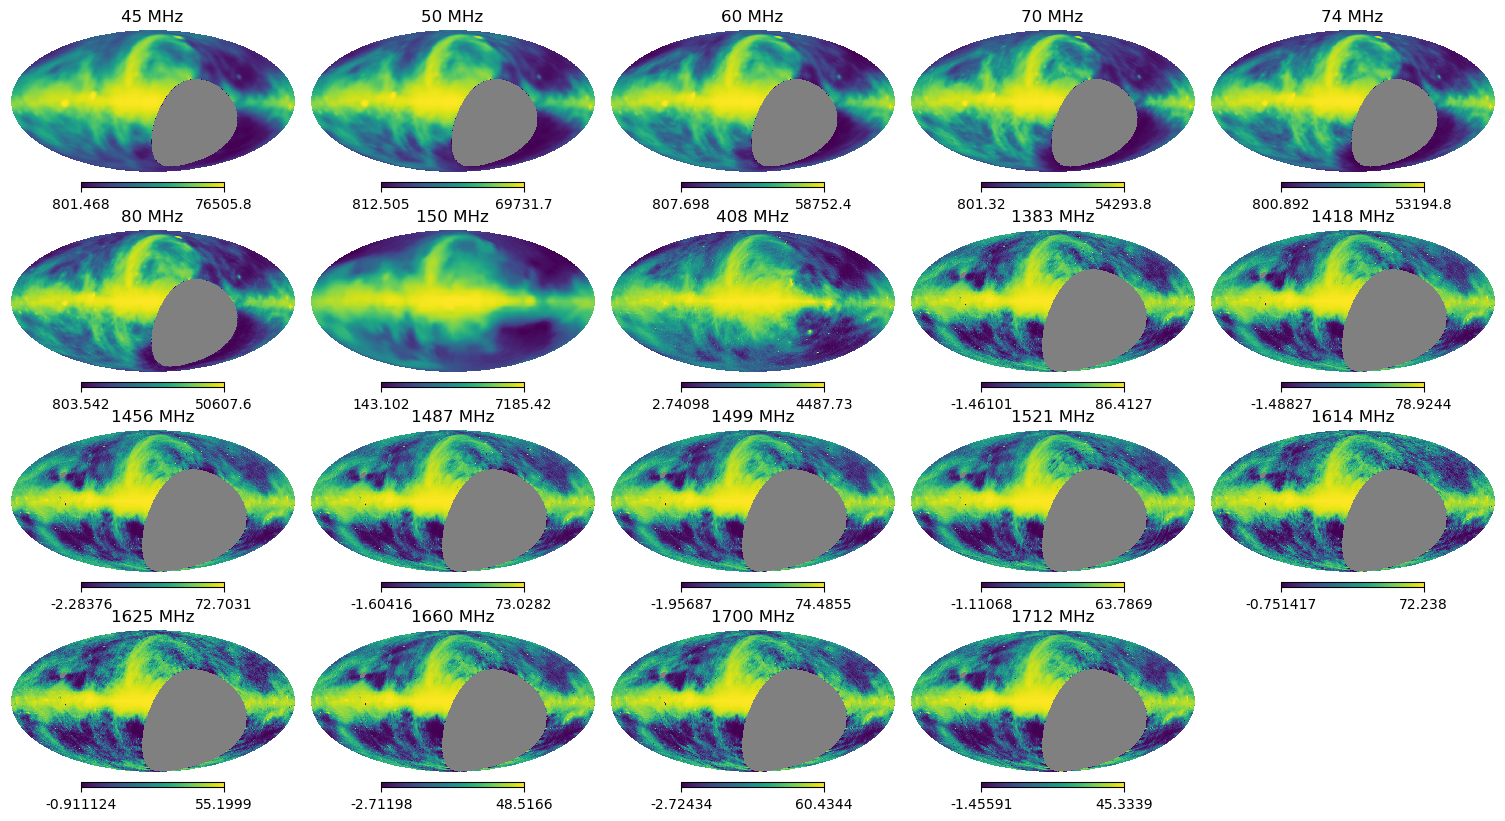

In [4]:
pl.figure(figsize=(15,10)) 

j=0
for fr,m in maps.items():
     
    hp.mollview( (m.value),  title=f'{fr} MHz'  , sub=(5,5,1+j) , notext=True ,norm='hist'   )
    
    j+=1

## 3. Smoothing to Common Resolution

All maps are smoothed to the lowest common resolution using: $\theta_{\rm smooth} = \sqrt{\theta_{\rm target}^2 - \theta_{\rm native}^2}$

In [5]:
  
freqs  =  np.array([  k for k in maps.keys()  ])  
fwhms = {45:3.6*u.deg,
        50:3.3*u.deg,
        60:2.7*u.deg,
        70:2.3*u.deg,
        74:2.2*u.deg,
        80:2.0*u.deg,
        150: 5. *u.deg ,
       408 :56*u.arcmin, 
       1383: 40.*u.arcmin,
       1418: 40.*u.arcmin,
       1456: 40.*u.arcmin,
       1487: 40.*u.arcmin,
       1499: 40.*u.arcmin,
       1521: 40.*u.arcmin,
       1614: 40.*u.arcmin,
       1625: 40.*u.arcmin,
       1660: 40.*u.arcmin,
       1700: 40.*u.arcmin,
       1712: 40.*u.arcmin,
        }

idmax = np.argmax([fwhms[f] .to(u.arcmin).value  for f in maps .keys()] )
fwhmax= fwhms[freqs[idmax]] 

## smooth maps to lowest  reso ~ 5 deg 
# downgrade them to nside=256 
print("smoothing and downgrading maps ")
noise_factor = {}
for k  in freqs:
    if k!=freqs[idmax]:  
        nans= np.ma.masked_invalid(maps[k] ).mask
        maps[k] [nans] =hp.UNSEEN *maps[k].unit
        maps[k] = hp.smoothing(maps[k]  , fwhm=pl.sqrt(fwhmax**2 - fwhms[k] **2 ).to(u.rad).value  )*maps[k].unit

    noise_factor[k] = np.sqrt(hp.nside2npix(hp.get_nside (maps[k ])) /hp.nside2npix( nside )  )

    if hp.get_nside(maps[k]) != nside  : 
        maps[k] = hp.ud_grade(maps[k].value , nside_out=nside )*maps[k].unit
    if k == 408:
      mapserr[k] = hp.smoothing(mapserr[k]  , fwhm=pl.sqrt(fwhmax**2 - fwhms[k] **2 ).to(u.rad).value  )*maps[k].unit
      mapserr[k] = hp.ud_grade(mapserr[k].value , nside_out=nside )*maps[k].unit


    nans= np.ma.masked_equal(maps[k].value, hp.UNSEEN  ).mask
    maps[k][nans] = np.nan 

smoothing and downgrading maps 


## 4. Noise and Calibration Uncertainties

Per-frequency instrumental noise estimates from calibration studies and survey documentation.

In [6]:

from scipy import integrate

def beamsolidangle(fwhm):
    """
    Given a FWHM resolution `fwhm`,
    it computes the solid angle subtended by a Gaussian-axisymmetric beam
     in steradians by performing :

    .. math::
        \Delta \Omega = \int d \phi  d\theta  \sin(theta) \e^{-\theta^2/(2\sigma_b^2)}
    """

    sigma = (fwhm / 2 / np.sqrt(2 * np.log(2))).to(u.rad).value
    
    x = np.linspace(0, 4 * sigma, 2048)
    Gaussian = lambda theta: np.exp(-((theta / (np.sqrt(2) * sigma)) ** 2))
    integrand = lambda theta: 2 * np.pi * np.sin(theta) * Gaussian(theta)
    Solid_angle = (
        integrate.quad(integrand, 0, x.max(), limit=1000, epsrel=1.0e-5)[0] * u.sr
    )
    return Solid_angle

errors ={} 

errors [50]=16 ### Jy/beam
errors[60] =10  ### Jy/beam
errors[70]= 7  ### Jy/beam
errors[74 ]= 6  ### Jy/beam
errors[80 ]= 5   ### Jy/beam

for i, v in errors.items() : 

    errors [i] = (v *u.Jy/beamsolidangle(fwhms[i])).to(u.K,equivalencies=u.brightness_temperature(i*u.MHz))

for f in fwhms.keys() : 
    if f >1000 : 
        errors [f] = (20  *u.mK).to(u.K ) # sect. 4 in https://iopscience.iop.org/article/10.3847/1538-3881/abf7c1/pdf  but table 5 states 20 mK  

errors[45 ]= 300 *u.K ##table 2 of https://aas.aanda.org/articles/aas/pdf/1997/11/ds1291.pdf 
errors[150]= 40 *u.K  #https://lambda.gsfc.nasa.gov/product/foreground/fg_all_sky150_mhzmap_info.html 
errors[408]= 0.1 *u.K # searching r.m.s. in https://arxiv.org/pdf/1411.3628 sigma_destr = 0.1 K 

storerrors ={} 
for f in maps.keys() : 
    storerrors[str(f)] = errors[f].value #/ noise_factor[f]

np.savez(f"../lwa_data/coarse_north_errors_dict.npz", **storerrors)



for k  in sorted(maps.keys())  : 
    print(f"At {k} MHz , map error is {storerrors[str(k)]} ")    

At 45 MHz , map error is 300.0 
At 50 MHz , map error is 55.44892726918175 
At 60 MHz , map error is 35.94864076200947 
At 70 MHz , map error is 25.47668569547423 
At 74 MHz , map error is 21.356767592579477 
At 80 MHz , map error is 18.42537982759134 
At 150 MHz , map error is 40.0 
At 408 MHz , map error is 0.1 
At 1383 MHz , map error is 0.02 
At 1418 MHz , map error is 0.02 
At 1456 MHz , map error is 0.02 
At 1487 MHz , map error is 0.02 
At 1499 MHz , map error is 0.02 
At 1521 MHz , map error is 0.02 
At 1614 MHz , map error is 0.02 
At 1625 MHz , map error is 0.02 
At 1660 MHz , map error is 0.02 
At 1700 MHz , map error is 0.02 
At 1712 MHz , map error is 0.02 


## 5. Zero-Level Offset Removal

Estimate and remove zero-level offsets using ODR correlation with the 408 MHz reference map.

In [7]:

offerr={}
off_map = {} 
offsetvals = {} 


offsetvals = {}
def remove_off(map, hasmap, maperr, haserr  ):
    nside_superpix=8
    nan1 =~np.ma.masked_invalid (map).mask 
    npix = map.size 
    pixs = np.arange(npix)
    super_nans = hp.ud_grade(nan1.astype('int'), nside_out=nside_superpix).astype('bool') 
    super_pixs = np.arange(super_nans.size ) [super_nans] 
     
    offsets = np.zeros_like(super_pixs  )*1. 
    offmap = np.full(hp.nside2npix(nside_superpix), np.nan)     
    nansize =0 

    for jj, ipix in enumerate(super_pixs ) : 

        super_map = np.zeros(hp.nside2npix(nside_superpix))
        super_map [ipix] =1
        

        patch =  (hp.ud_grade(super_map, nside_out=hp.get_nside(map))) .astype('bool')
     
        try:
            
            errx = haserr[patch] * hasmap[patch]
            erry =  maperr * map[patch]
            mydata = Data(hasmap[patch], map[patch], wd=errx**-2, we=erry**-2)
            myodr = ODR(mydata, Model(sform), beta0=[0.0, 0.0])
            myoutput = myodr.run()
            cfit = myoutput.beta[1]
            if np.corrcoef(hasmap[patch].value, map[patch].value)[0,1] > 0.75:
                offsets[jj] = cfit
            else:
                offsets[jj] = np.nan
        except  ValueError: 
            nansize+=1 
            offsets[jj]= np.nan 

    offmap[super_pixs] = offsets

    #avec = np.nanmean( offsets ) *map.unit
    avec = np.nanmedian( offsets ) *map.unit
    map = map - avec
    
    return map, avec  , np.nanstd(offsets) /np.sqrt(offsets.size - nansize), offmap 

for k in maps.keys():
    if k ==408 : continue
    maps[k], offsetvals[k], offerr[k], off_map[k] = remove_off(maps[k], maps[408], mapserr[k], mapserr[408])
    print(f" {k} MHz data estimated offset: {offsetvals[k]:.4f} ± {offerr[k]:.4f}")


 45 MHz data estimated offset: 2860.8023 K ± 105.8035
 50 MHz data estimated offset: 2290.1954 K ± 78.9087
 60 MHz data estimated offset: 1608.4275 K ± 48.1898
 70 MHz data estimated offset: 1126.5665 K ± 29.4457
 74 MHz data estimated offset: 1026.4759 K ± 25.0338
 80 MHz data estimated offset: 845.0899 K ± 21.1837
 150 MHz data estimated offset: 83.3280 K ± 6.0852
 1383 MHz data estimated offset: -0.3965 K ± 0.0196
 1418 MHz data estimated offset: -0.3298 K ± 0.0179
 1456 MHz data estimated offset: -0.3144 K ± 0.0151
 1487 MHz data estimated offset: -0.3203 K ± 0.0155
 1499 MHz data estimated offset: -0.3196 K ± 0.0154
 1521 MHz data estimated offset: -0.3398 K ± 0.0142
 1614 MHz data estimated offset: -0.2832 K ± 0.0125
 1625 MHz data estimated offset: -0.2422 K ± 0.0139
 1660 MHz data estimated offset: -0.2631 K ± 0.0126
 1700 MHz data estimated offset: -0.2263 K ± 0.0115
 1712 MHz data estimated offset: -0.2184 K ± 0.0118


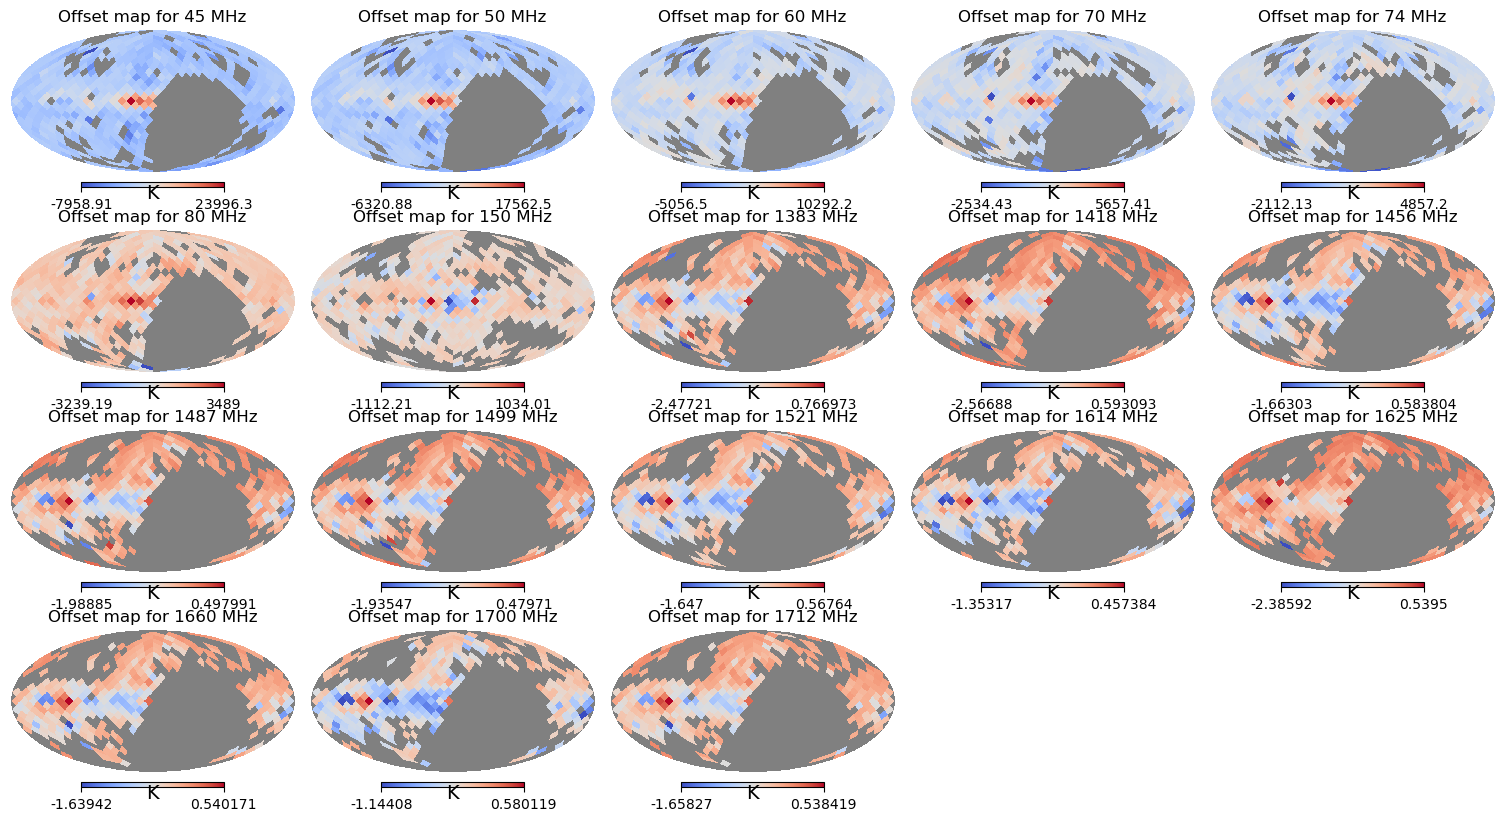

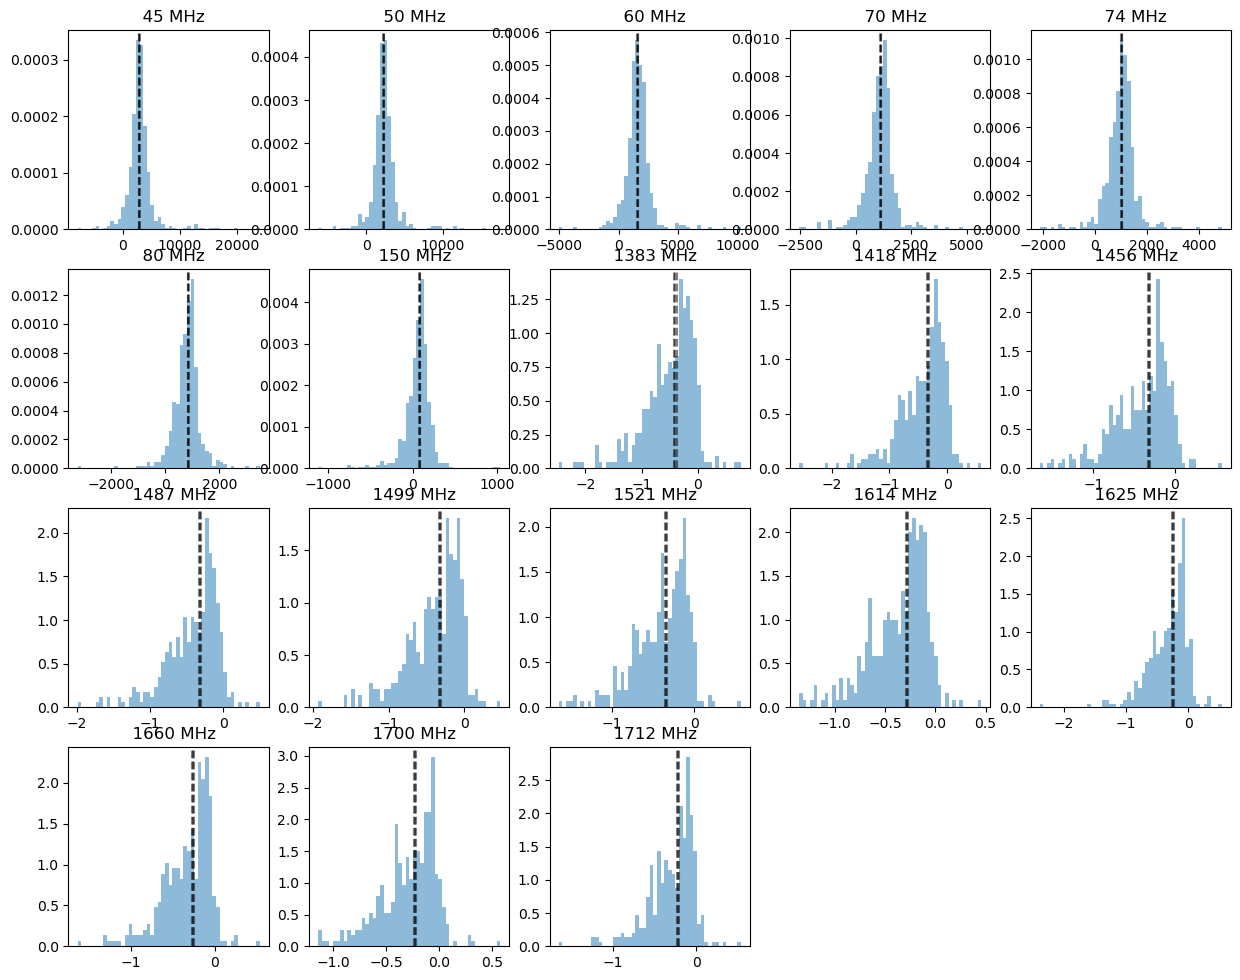

In [8]:
output_dir = "../outputs"
os.makedirs(output_dir, exist_ok=True)

j=0
pl.figure(figsize=(15, 10))

for k,   offset_map  in off_map.items():
    hp.mollview(offset_map, title=f"Offset map for {k} MHz", unit=f"{maps[k].unit}" , cmap='coolwarm',
                sub=(5,5,j+1))
    j+=1

offset_file = open(output_dir+'/offset_coarse_north.txt', 'w')

pl.figure(figsize=(15, 15))
j=0
for k, offset in offsetvals.items():
    error_offset = offerr[k] 
    offset_map = off_map[k] 

    offset_file.write("%f %f % f\n" %(k, offset.value, error_offset))
    pl.subplot(5, 5, j+1)
    pl.title(f"  {k} MHz") 
    pl.hist(np.ma.masked_invalid(offset_map ).data.flatten(), bins=50, label=f"{k} MHz", alpha=0.5, density=True)
    pl.axvline ( offset.value,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    pl.axvline ( offset.value -error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    pl.axvline ( offset.value +error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    j+=1

offset_file.close()

/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_4004/134311547.py:6: RuntimeWarning: invalid value encountered in log
  hp.mollview(np.log (m.value),  title=f'{fr} MHz'  , sub=(4,5,1+j) , notext=True ,  min=-1,  max=10 , unit = f'log({m.unit})'   , cmap='inferno')


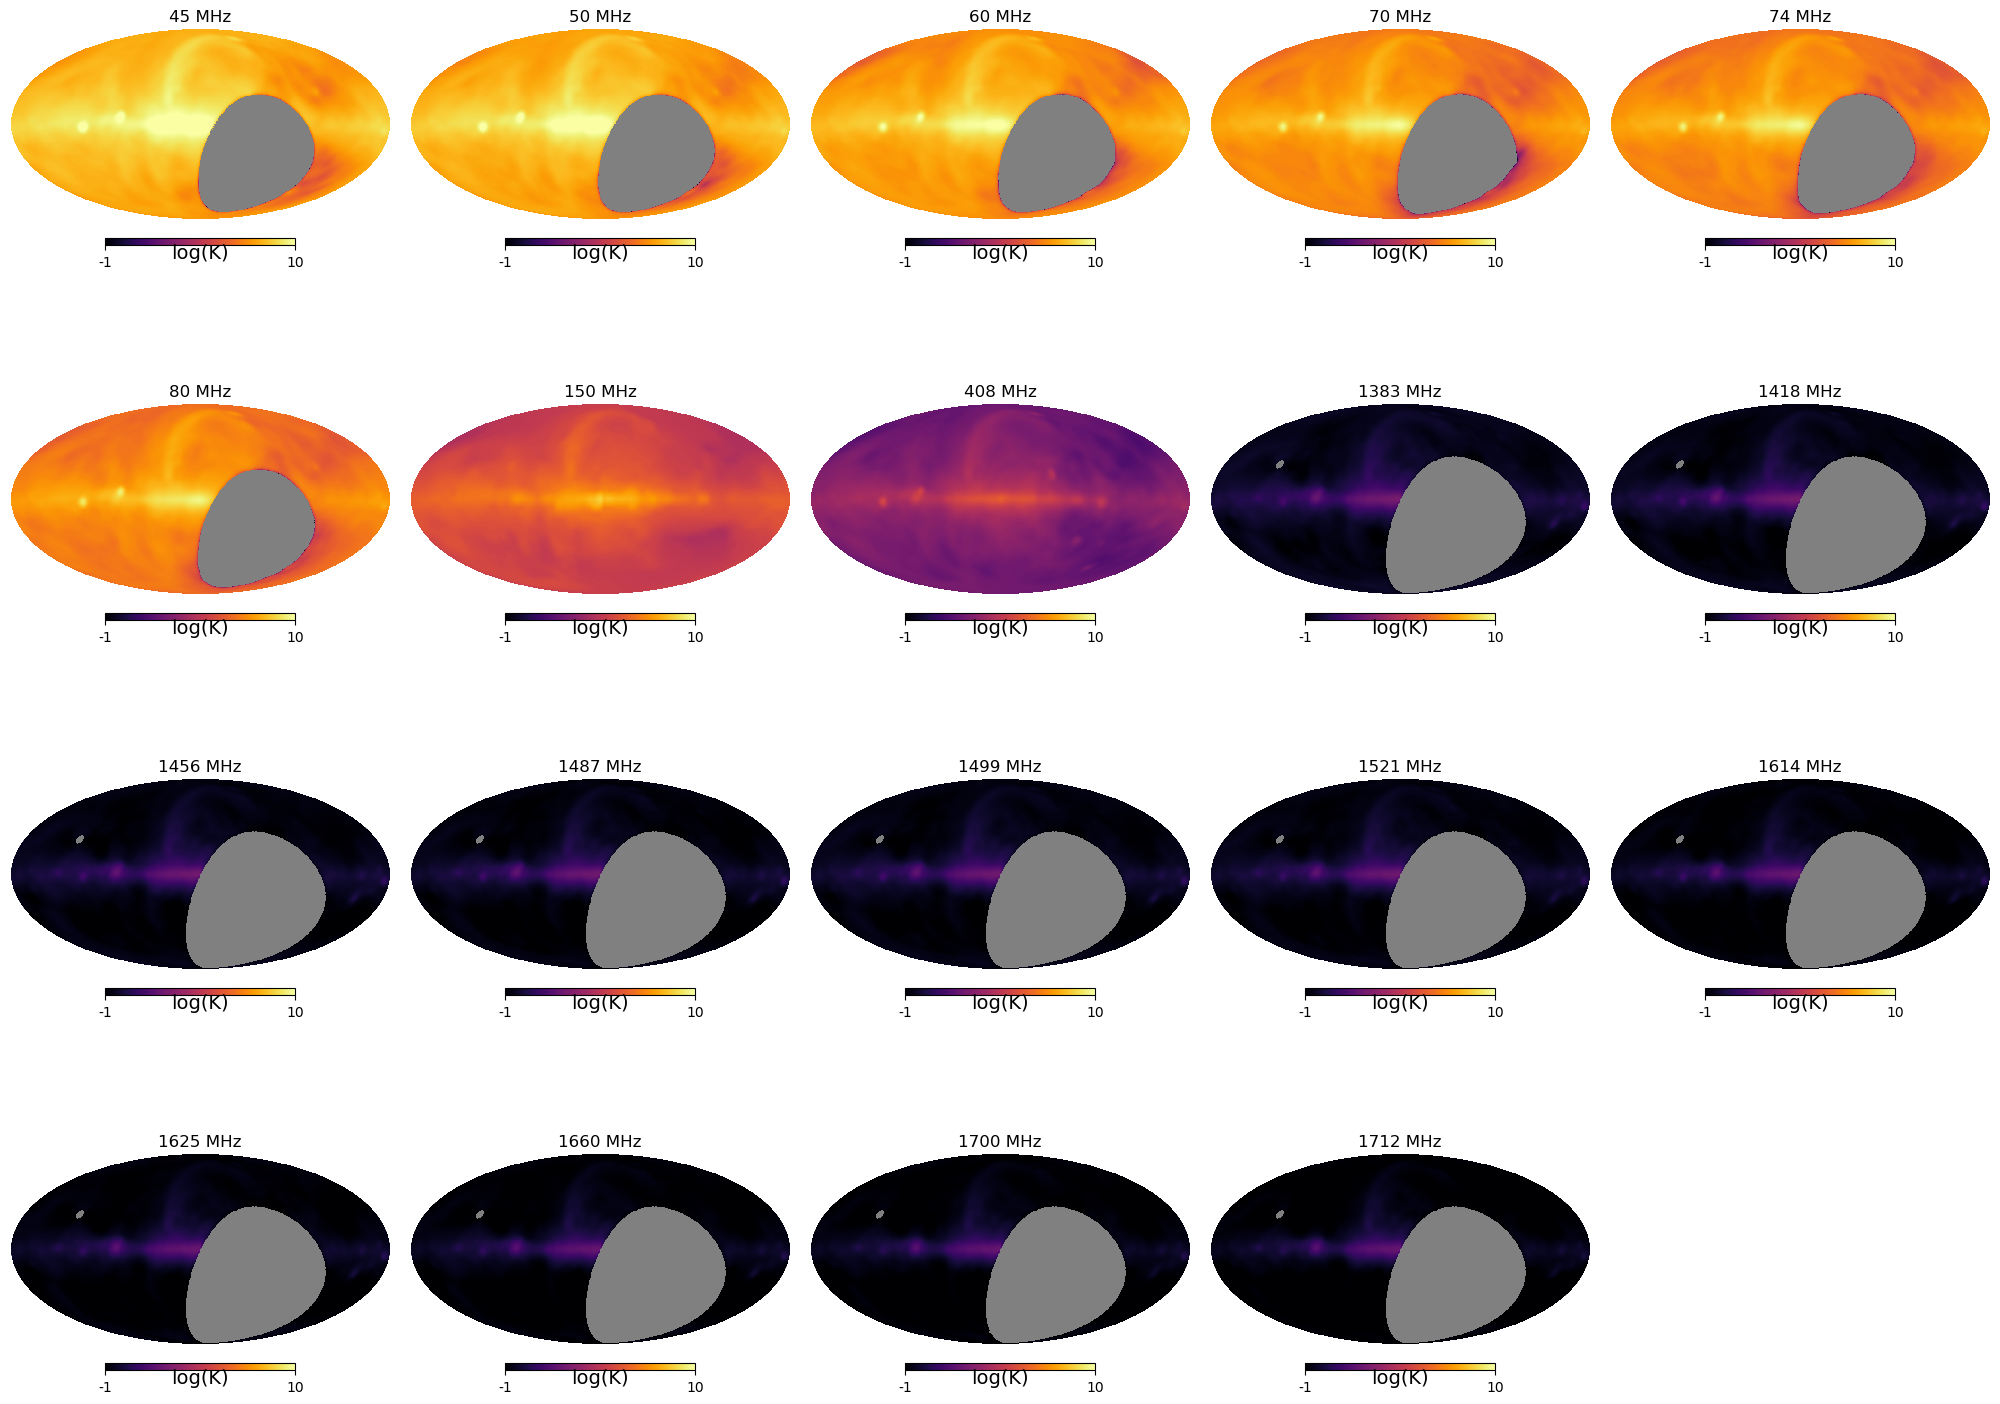

In [9]:
pl.figure(figsize=(20,15)) 

j=0
for fr,m in maps.items():
     
    hp.mollview(np.log (m.value),  title=f'{fr} MHz'  , sub=(4,5,1+j) , notext=True ,  min=-1,  max=10 , unit = f'log({m.unit})'   , cmap='inferno')
    
    j+=1

## 6. Save Output Products

Export preprocessed maps for downstream spectral analysis.

In [10]:

from astropy.table import Table
t = Table([m for m in maps.values() ] , names=(m for m in maps.keys()))

t.write(f'../lwa_data/coarse_north_maps_nside{nside}.fits', format='fits', overwrite=True )

## 7. Validation

Compute and save the common sky footprint for all surveys.

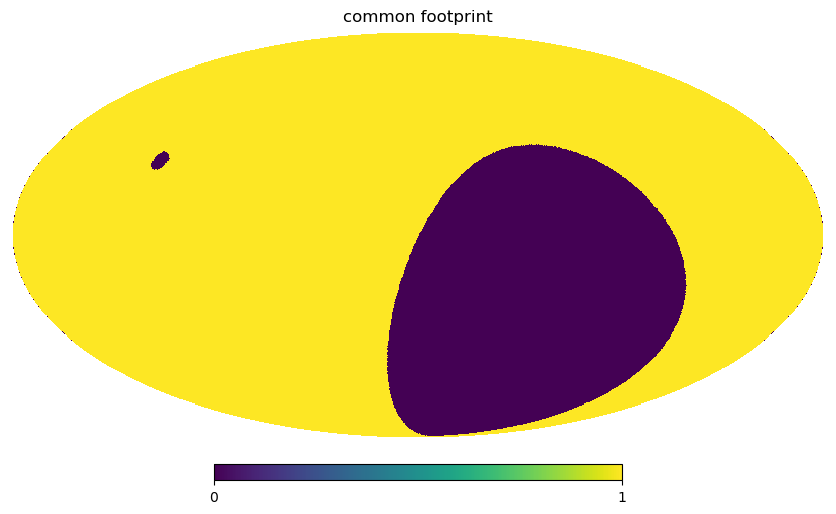

In [11]:
lwa_nans = np.ma.masked_invalid(maps[45] ).mask  
gmims_nans = np.ma.masked_invalid(maps[1383] ).mask
common_footprint =  np.logical_and(~lwa_nans , ~gmims_nans)  
hp.mollview(common_footprint, title='common footprint' ) 
j=0 


In [12]:
hp.write_map(
    f"{output_dir}/common_footprint_northern.fits",
    common_footprint.astype(np.float32),
    overwrite=True
)

setting the output map dtype to [dtype('float32')]
